In [1]:
import scanpy as sc
import pandas as pd

import sys, os

import matplotlib.pyplot as plt
import palettable

In [2]:
import os, sys
os.chdir('../../data')
sys.path.append('../src')

In [3]:
os.chdir('../analysis')

d10_lapa_dz_clustered = sc.read_h5ad('clustered_egfDuod_D10_Lapa_DZ.h5ad')

### Create a new object for our EEC cells

In [4]:
clusters_to_keep = ["5"]            # or ["3","7","9"]
leiden_key = "leiden"

mask = d10_lapa_dz_clustered.obs[leiden_key].isin(clusters_to_keep)
EECs_clustered = d10_lapa_dz_clustered[mask].copy() 

In [5]:
EECs_clustered

AnnData object with n_obs × n_vars = 1397 × 28395
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'X_name', 'hvg'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

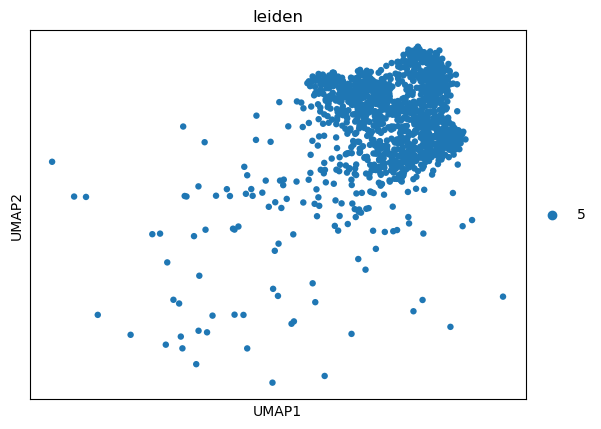

In [6]:
sc.pl.umap(EECs_clustered, color = 'leiden')

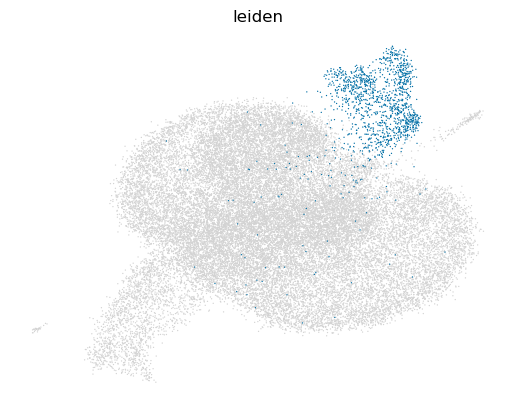

In [7]:
sc.pl.umap(
    d10_lapa_dz_clustered,
    color="leiden",
    palette=sc.pl.palettes.default_102,  # or sc.pl.palettes.zeileis_28
    groups=["5"],                 # highlight only this group
    frameon=False,
    legend_loc=None,                  # hide legend if you like
)

/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)
/opt/anaconda3/envs/single-cell-env/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
/opt/anaconda3/envs/single-cell-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/gs/k55rgtm50g938k87mvcdclqr0000gq/T/ipykernel_81846/2923572028.py:21: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc

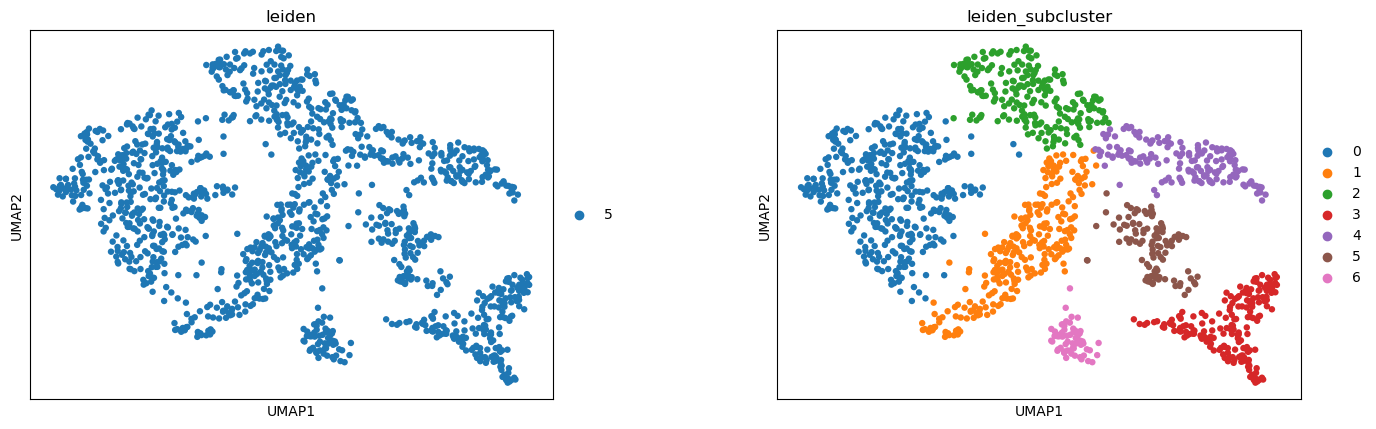

In [8]:
### Recluster

if "counts" in EECs_clustered.layers:
    EECs_clustered.X = EECs_clustered.layers["counts"].copy()
    sc.pp.filter_genes(EECs_clustered, min_counts=1)
    sc.pp.normalize_total(EECs_clustered, target_sum=1e4)
    sc.pp.log1p(EECs_clustered)

# Standard preprocessing
sc.pp.highly_variable_genes(EECs_clustered, n_top_genes=3000, flavor="seurat_v3")
adata_sub = EECs_clustered[:, EECs_clustered.var["highly_variable"]].copy()

sc.pp.scale(adata_sub, max_value=10)
sc.tl.pca(adata_sub, n_comps=50, svd_solver="arpack")

# Graph + UMAP
sc.pp.neighbors(adata_sub, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_sub)

# --- Recluster and save to a NEW slot ---
sc.tl.leiden(
    adata_sub,
    resolution=0.3,
    key_added="leiden_subcluster"   # <- new column in .obs
)

# (Nice-to-have) ensure string/categorical with clean ordering
adata_sub.obs["leiden_subcluster"] = (
    adata_sub.obs["leiden_subcluster"].astype(str).astype("category")
)

# Quick check
sc.pl.umap(adata_sub, color=["leiden", "leiden_subcluster"], wspace=0.3)

### Plot the hormonal markers, by subcluster


In [9]:
Enterochromaffin_markers = ["CHGA", "TPH1", "NEUROD1"]

Peptide_cell_markers = ["ARX", "MLN", "GHRL", "GAST", "GIP", "CCK"]



EEC_marker_dictionary = {
    "Enterochromaffin_markers": ["CHGA", "TPH1", "NEUROD1"],
    "Peptide_cell_marker": ["ARX"],
    "M_cell_marker": ["MLN"],
    "X_cell_marker": ["GHRL"],
    "K_cell_marker": ["GIP"],
    "I_cell_marker": ["CCK"]


}


In [10]:
adata_sub

AnnData object with n_obs × n_vars = 1397 × 3000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'freemuxlet.identity', 'participant', 'Condition', 'Time_point', 'Treatment', 'ident', 'leiden', 'leiden_subcluster'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'n_counts', 'highly_variable_rank', 'variances', 'variances_norm'
    uns: 'X_name', 'hvg', 'leiden_colors', 'log1p', 'pca', 'neighbors', 'umap', 'leiden_subcluster', 'leiden_subcluster_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [11]:
import scanpy as sc
import numpy as np
import pandas as pd

adata = adata_sub  # <-- or your AnnData
cluster_key = "leiden_subcluster"         # change if you used a different key

# Example markers dict:
# markers = {"Stem/ISC": ["LGR5", "ASCL2"], "Enterocyte": ["ALPI","APOA1"], ...}
# (Use your own dict here)
markers = EEC_marker_dictionary

# — ensure leiden is categorical & optional dendrogram ordering —
adata.obs[cluster_key] = adata.obs[cluster_key].astype("category")
sc.tl.dendrogram(adata, groupby=cluster_key)  # enables consistent ordering across plots

# — keep only genes present in adata.var_names (case-sensitive) —
varset = set(adata.var_names)
filtered_markers = {k: [g for g in v if g in varset] for k, v in markers.items()}
missing = {k: sorted(set(v) - varset) for k, v in markers.items() if any(g not in varset for g in v)}

# (optional) quick notice in notebook:
print("Missing genes (ignored):")
for k, lst in missing.items():
    if lst: print(f"  {k}: {', '.join(lst)}")

# If you prefer uppercase matching, uncomment this mapping:
# name_map = {g.upper(): g for g in adata.var_names}
# filtered_markers = {k: [name_map[g] for g in v if g.upper() in name_map] for k,v in markers.items()}


Missing genes (ignored):


categories: 0, 1, 2, etc.
var_group_labels: Enterochromaffin_markers, Peptide_cell_marker, M_cell_marker, etc.
categories: 0, 1, 2, etc.
var_group_labels: Enterochromaffin_markers, Peptide_cell_marker, M_cell_marker, etc.


{'mainplot_ax': <Axes: >,
 'group_extra_ax': <Axes: >,
 'gene_group_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

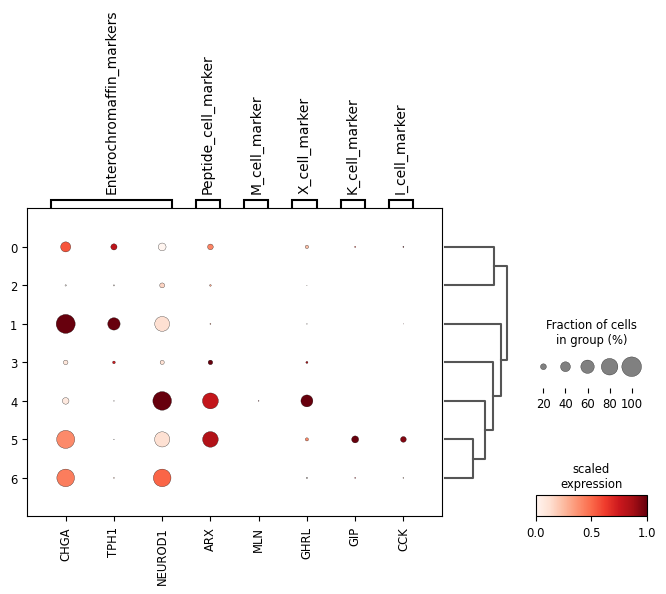

In [12]:
sc.pl.dotplot(
    adata,
    filtered_markers,              # dict[group] = list of genes
    groupby=cluster_key,
    dendrogram=True,               # uses the sc.tl.dendrogram result
    standard_scale="var",          # scale per gene for comparability
    mean_only_expressed=True,      # makes size reflect % expressing, color = mean
    swap_axes=False,               # clusters on x-axis (set True to flip)
    show=False,
    colorbar_title="scaled\nexpression",
    figsize=(8, 4)
)
# Save exactly like Scanpy expects (relative to sc.settings.figdir if set)
sc.pl.dotplot(
    adata,
    filtered_markers,
    groupby=cluster_key,
    dendrogram=True,
    standard_scale="var",
    mean_only_expressed=True,
    show=False,
    save="_markers_by_leiden_dotplot.pdf"   # yields e.g. 'figures/dotplot_markers_by_leiden_dotplot.pdf'
)


### Panels on the UMAP


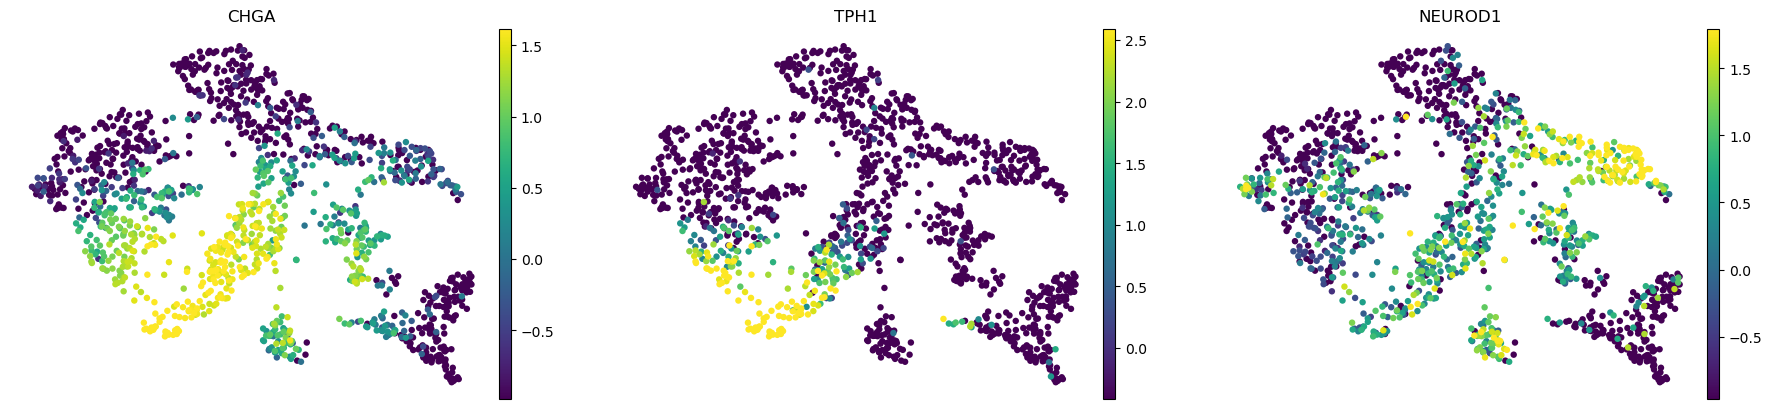

In [13]:



present = [g for g in Enterochromaffin_markers
           if (hasattr(adata, "raw") and adata.raw is not None and g in adata.raw.var_names) or
              (g in adata.var_names)]

sc.pl.umap(
    adata,
    color=present,
    ncols=4,          # show expression from .raw if you froze it
    vmax="p95",            # nicer dynamic range
    frameon=False
)

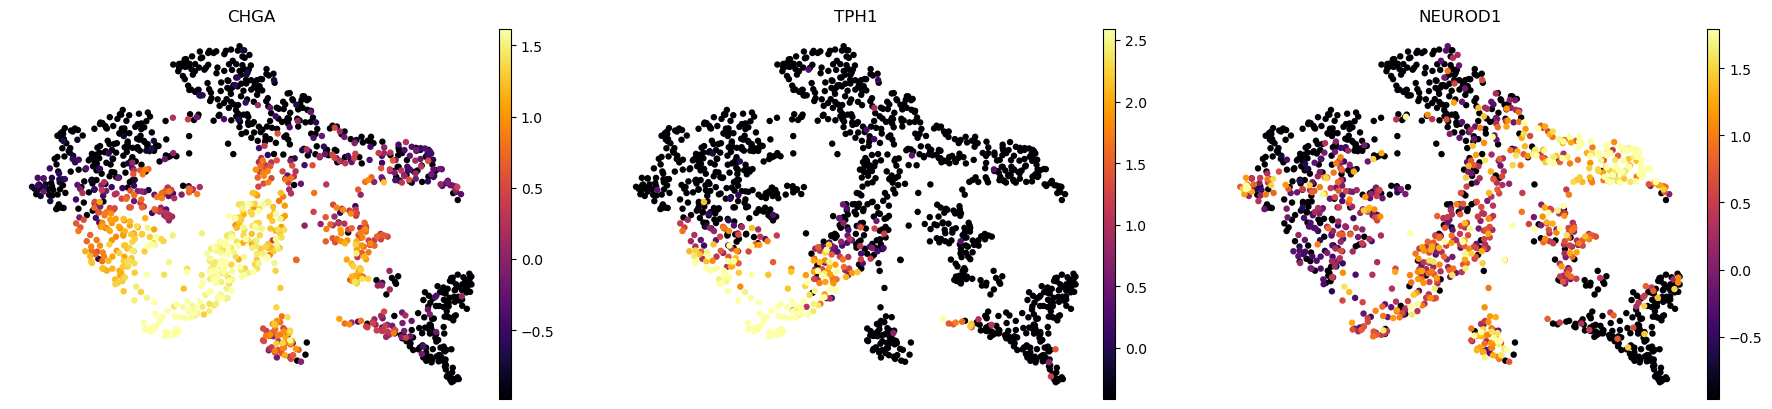

In [14]:
sc.pl.umap(
    adata,
    color=present,
    ncols=4,   
    cmap="inferno",# show expression from .raw if you froze it
    vmax="p95",            # nicer dynamic range
    frameon=False
)





#### Peptide cell markers

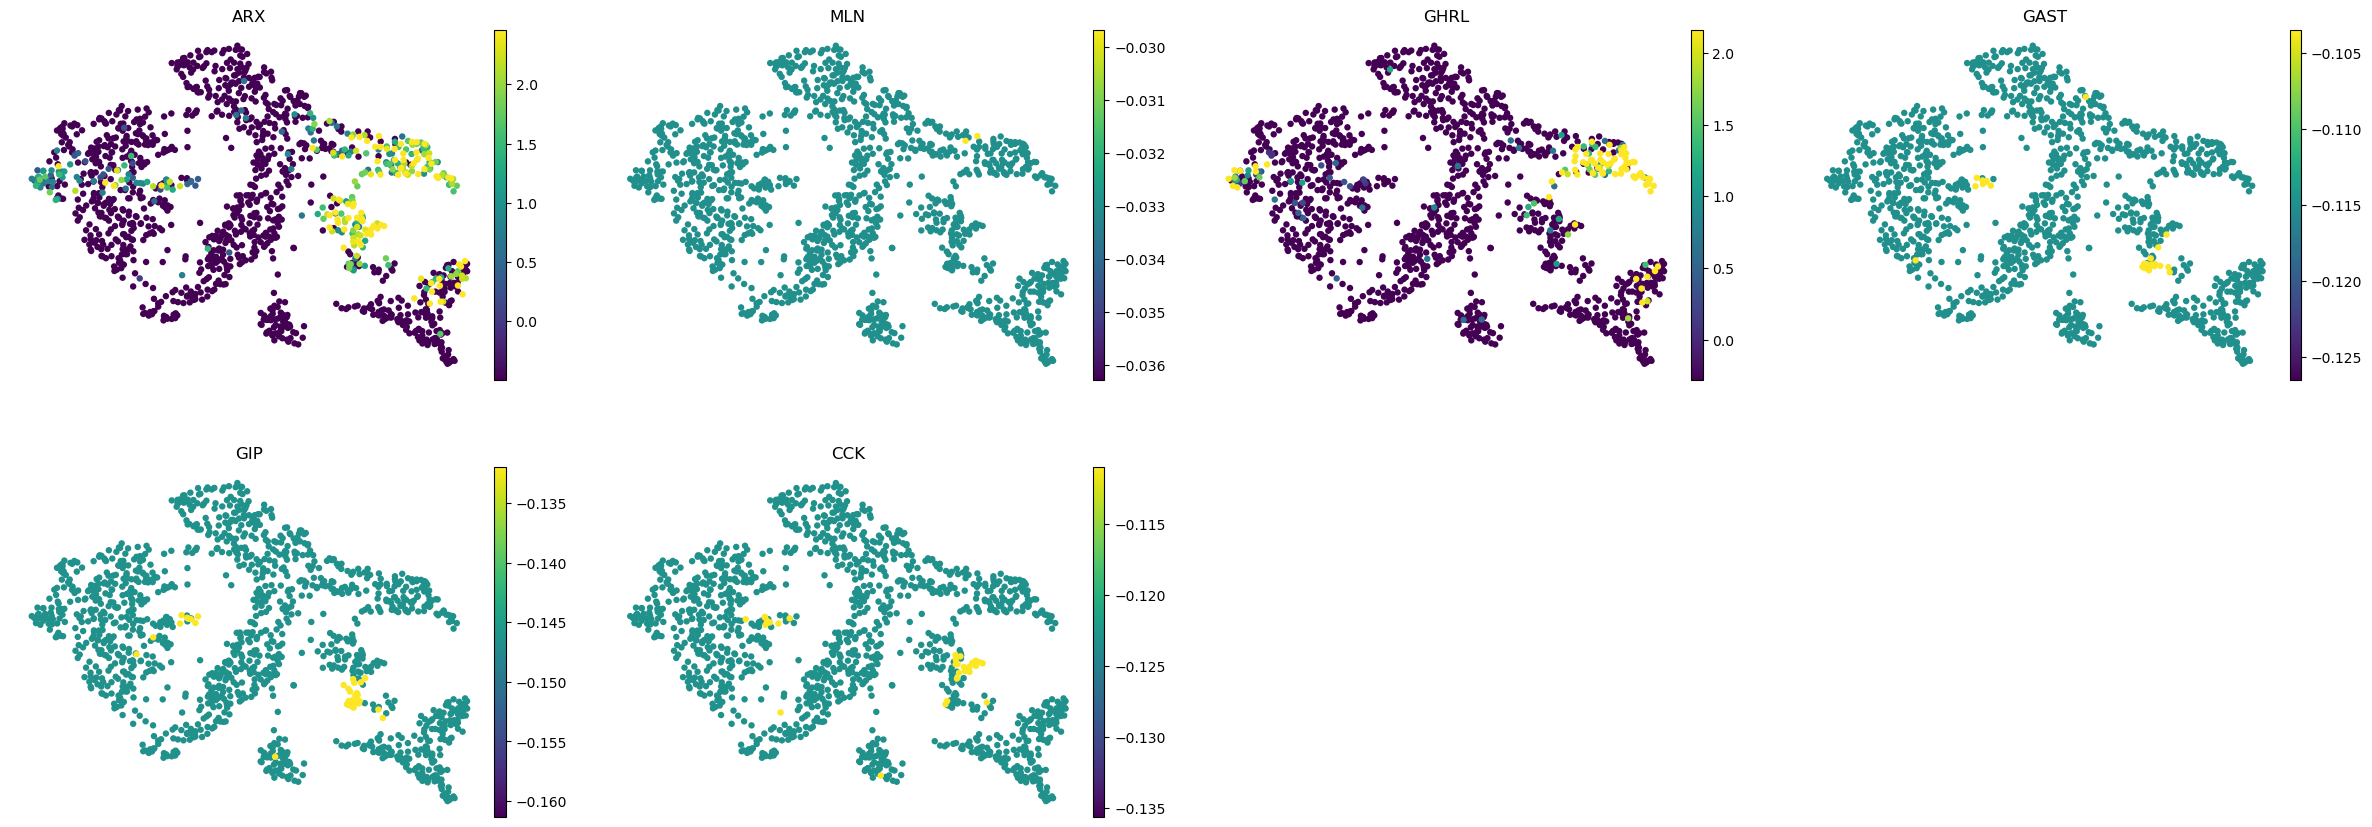

In [15]:



present = [g for g in Peptide_cell_markers
           if (hasattr(adata, "raw") and adata.raw is not None and g in adata.raw.var_names) or
              (g in adata.var_names)]

sc.pl.umap(
    adata,
    color=present,
    ncols=4,          # show expression from .raw if you froze it
    vmax="p95",            # nicer dynamic range
    frameon=False
)

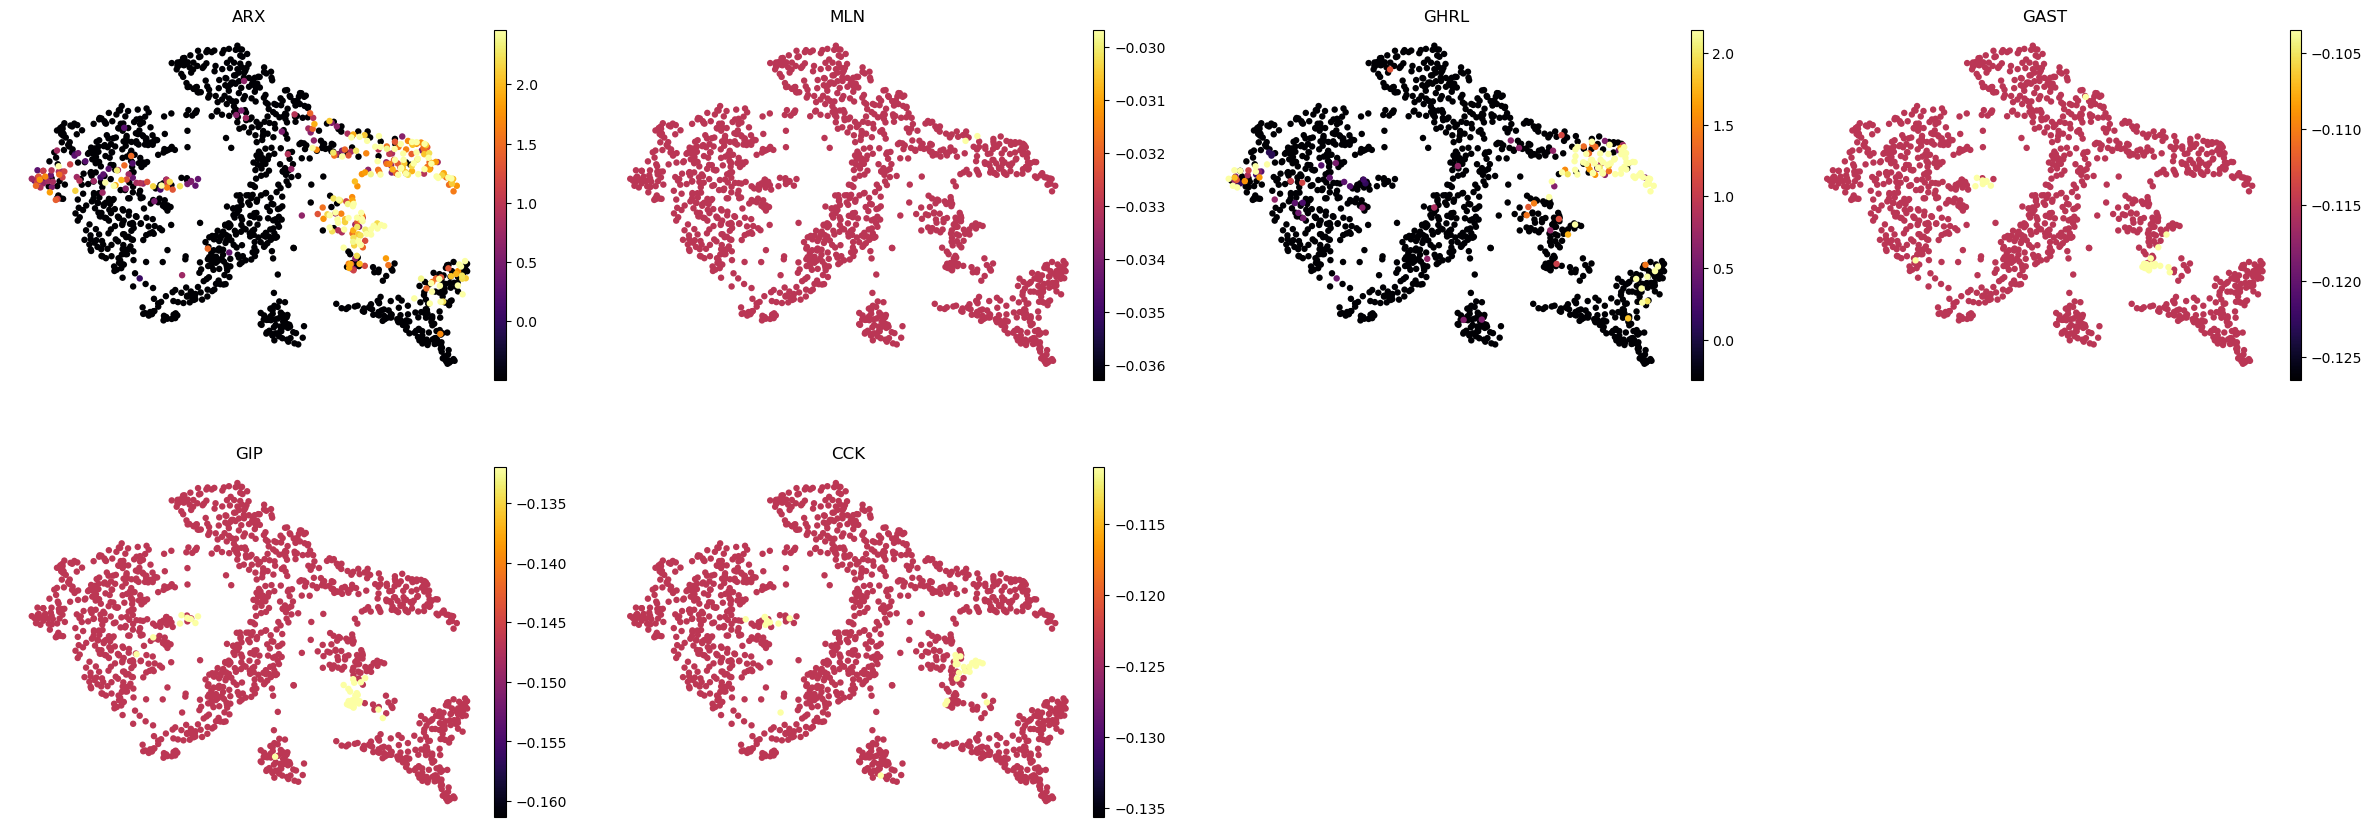

In [16]:
sc.pl.umap(
    adata,
    color=present,
    ncols=4,
    cmap="inferno",# show expression from .raw if you froze it          # show expression from .raw if you froze it
    vmax="p95",            # nicer dynamic range
    frameon=False
)

#### Pax4, and Chromogranin-B expression

In [17]:
Additional_markers = ["CHGB", "PAX4", "ATOH1"]

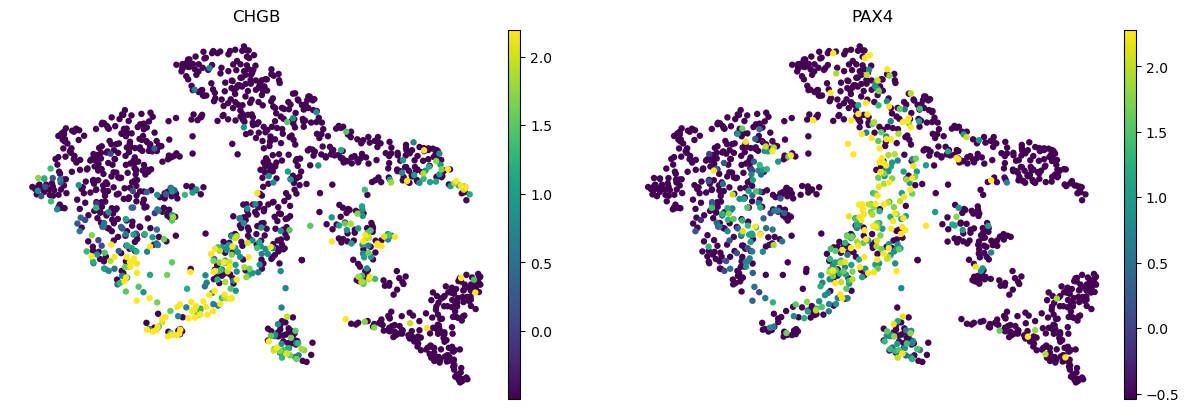

In [18]:



present = [g for g in Additional_markers
           if (hasattr(adata, "raw") and adata.raw is not None and g in adata.raw.var_names) or
              (g in adata.var_names)]

sc.pl.umap(
    adata,
    color=present,
    ncols=4,          # show expression from .raw if you froze it
    vmax="p95",            # nicer dynamic range
    frameon=False
)

#### Plot PERCC1 & FAM181B

In [22]:
Cofactors = ["PERCC1", "FAM181B"]


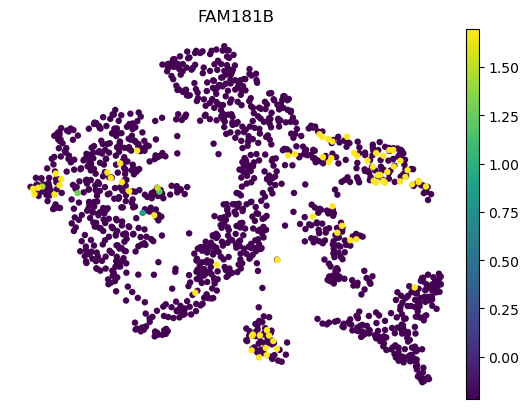

In [24]:
present = [g for g in Cofactors
           if (hasattr(adata, "raw") and adata.raw is not None and g in adata.raw.var_names) or
              (g in adata.var_names)]

sc.pl.umap(
    adata,
    color=present,
    ncols=4,          # show expression from .raw if you froze it
    vmax="p95",         
    frameon=False
)

In [ ]:
## Save our clustered data

intermediate_directory = '/Users/stanleydale/user_generated/breault-lab/single-cell/analysis'
sc.write(f'{intermediate_directory}/subclustered_EECs_egfDuod_D10_Lapa_DZ.h5ad', adata)